In [ ]:
# ============================================
# RABTECH ACADEMY - TASK 02
# ML Problem Framing & Responsible Data Card
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving customer-churn-training.csv to customer-churn-training.csv


In [ ]:
import os

print("Uploaded files:")

for file in os.listdir():
    print(file)

Uploaded files:
.config
customer-churn-training.csv
.ipynb_checkpoints
sample_data


In [ ]:
import pandas as pd

df = pd.read_csv("customer-churn-training.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 12
Columns: 7


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Column names:
['customer_id', 'tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type', 'churned']

First 5 rows:


,customer_id,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type,churned
0,C001,2,4,499,21,Basic,1
1,C002,18,1,1299,2,Pro,0
2,C003,6,3,799,14,Basic,1
3,C004,30,0,1499,1,Pro,0
4,C005,11,2,999,5,Standard,0


In [ ]:
print("Dataset Information")
print("=" * 50)
df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        12 non-null     object
 1   tenure_months      12 non-null     int64 
 2   support_tickets    12 non-null     int64 
 3   monthly_spend_inr  12 non-null     int64 
 4   last_login_days    12 non-null     int64 
 5   plan_type          12 non-null     object
 6   churned            12 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 804.0+ bytes


In [ ]:
# Target variable
TARGET_COLUMN = "churned"

print("Target column:", TARGET_COLUMN)
print("\nTarget values:")
print(df[TARGET_COLUMN].value_counts())

Target column: churned

Target values:
churned
0    7
1    5
Name: count, dtype: int64


In [ ]:
print("Churn Distribution")
print("=" * 40)

churn_counts = df["churned"].value_counts()

print("Not Churned (0):", churn_counts.get(0, 0))
print("Churned (1):", churn_counts.get(1, 0))

print("\nPercentage:")
print(
    df["churned"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn Distribution
Not Churned (0): 7
Churned (1): 5

Percentage:
churned
0    58.33
1    41.67
Name: proportion, dtype: float64


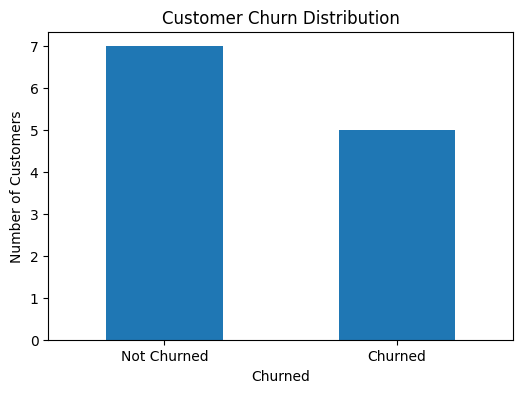

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

df["churned"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")
plt.xticks(
    [0, 1],
    ["Not Churned", "Churned"],
    rotation=0
)

plt.show()

In [ ]:
missing_report = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

display(missing_report)

,Column,Missing_Count,Missing_Percentage
customer_id,customer_id,0,0.0
tenure_months,tenure_months,0,0.0
support_tickets,support_tickets,0,0.0
monthly_spend_inr,monthly_spend_inr,0,0.0
last_login_days,last_login_days,0,0.0
plan_type,plan_type,0,0.0
churned,churned,0,0.0


In [ ]:
print("Total duplicate rows:", df.duplicated().sum())

print(
    "Duplicate customer IDs:",
    df["customer_id"].duplicated().sum()
)

Total duplicate rows: 0
Duplicate customer IDs: 0


In [ ]:
X = df.drop(columns=["churned", "customer_id"])
y = df["churned"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type']

Target:
churned


In [ ]:
print("Plan types:")
print(df["plan_type"].value_counts())

Plan types:
plan_type
Basic       5
Standard    4
Pro         3
Name: count, dtype: int64


In [ ]:
print("Numerical Feature Statistics")
print("=" * 50)

display(
    df[
        [
            "tenure_months",
            "support_tickets",
            "monthly_spend_inr",
            "last_login_days"
        ]
    ].describe()
)

Numerical Feature Statistics


,tenure_months,support_tickets,monthly_spend_inr,last_login_days
count,12.000000,12.000000,12.000000,12.000000
mean,12.166667,2.250000,915.666667,10.000000
std,9.242524,1.602555,332.574895,9.095453
min,1.000000,0.000000,499.000000,1.000000
25%,5.500000,1.000000,724.000000,2.750000
50%,9.500000,2.000000,899.000000,7.000000
75%,18.500000,3.250000,1074.000000,14.750000
max,30.000000,5.000000,1499.000000,30.000000


In [ ]:
## Sensitive Attribute Review

The supplied dataset was reviewed for obvious demographic or sensitive attributes.

No explicit demographic attributes such as gender, religion, ethnicity, disability, or health information were identified in the inspected columns.

The `monthly_spend_inr` feature may indirectly reflect a customer's purchasing or economic circumstances. Its use should therefore be reviewed for business necessity and potential unintended effects.

The `customer_id` field is treated as an identifier and is excluded from model features.

In [ ]:
# ML Problem-Framing Memo

## 1. Problem Statement

The objective is to identify customers who may be at risk of leaving the service so that appropriate retention actions can be considered.

## 2. Ideal Outcome

The desired outcome is to identify potentially at-risk customers early enough for the organization to review their situation and, where appropriate, take a suitable retention action.

## 3. Machine Learning Goal

The machine-learning system will predict whether a customer is likely to churn based on information available about the customer.

## 4. Problem Type

This is a supervised binary classification problem.

## 5. Prediction Target

The target variable is:

`churned`

Where:

- `0` = Customer did not churn
- `1` = Customer churned

## 6. Unit of Observation

One row represents one customer.

## 7. Input Features

The candidate input features are:

- `tenure_months`
- `support_tickets`
- `monthly_spend_inr`
- `last_login_days`
- `plan_type`

## 8. Identifier

`customer_id` is treated as an identifier and is excluded from model training.

## 9. Action

A high-risk prediction can be used to prioritize a customer for an appropriate retention review.

The model should not automatically make an irreversible decision about the customer.

## 10. Action Window

This educational dataset does not specify a precise operational prediction window.

For a real deployment, the organization should define when the prediction is made and how long the resulting risk assessment remains valid.

## 11. Non-ML Baseline

The baseline predicts the majority class for every customer.

The ML model is compared against this baseline.

## 12. Success Metrics

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

Recall is particularly important when missing an actual churner has a significant business cost.

## 13. Business Consideration

False positives and false negatives have different costs.

The actual monetary or operational costs should be determined using real business information rather than assumed from this educational dataset.

In [ ]:
# Sensitive Attribute Review

The supplied dataset was reviewed for obvious demographic or sensitive attributes.

The observed columns are:

- `customer_id`
- `tenure_months`
- `support_tickets`
- `monthly_spend_inr`
- `last_login_days`
- `plan_type`
- `churned`

No explicit demographic attributes such as gender, religion, ethnicity, disability, or health information were observed in these columns.

However, `monthly_spend_inr` may indirectly relate to a customer's economic circumstances. Its use should therefore be reviewed for business necessity and potential unintended effects.

The `customer_id` field is treated as an identifier and is excluded from model training.

Before real-world use, the dataset owner should review whether any additional sensitive information exists outside the supplied columns.

In [ ]:
# Data Leakage Risk Review

Data leakage occurs when information that would not legitimately be available at prediction time is used by the model.

The candidate features are:

- `tenure_months`
- `support_tickets`
- `monthly_spend_inr`
- `last_login_days`
- `plan_type`

The target variable `churned` is not used as an input feature.

The `customer_id` field is excluded because it is an identifier.

Before production deployment, each feature should be checked to confirm that it is available at the defined prediction time.

Information created after the churn event or information that directly reveals the churn outcome must not be used as a predictive feature.

The dataset does not provide a complete event timeline, so the exact feature availability time should be verified with the data owner.

In [ ]:
# ============================================
# CELL 15 - NON-ML MAJORITY CLASS BASELINE
# ============================================

import pandas as pd
import numpy as np
from google.colab import files

# Upload the CSV file
print("Please upload customer-churn-training.csv")

uploaded = files.upload()

# Get the uploaded file name automatically
filename = list(uploaded.keys())[0]

print("\nFile uploaded successfully:", filename)

# Read the dataset
df = pd.read_csv(filename)

# Display basic information
print("\nDataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Target column
y = df["churned"]

# Find the most common class
majority_class = y.mode()[0]

# Predict the majority class for every customer
baseline_predictions = np.full(
    len(y),
    majority_class
)

# Calculate baseline metrics
baseline_accuracy = accuracy_score(
    y,
    baseline_predictions
)

baseline_precision = precision_score(
    y,
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    y,
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    y,
    baseline_predictions,
    zero_division=0
)

# Display results
print("\nNON-ML MAJORITY CLASS BASELINE")
print("=" * 50)
print("Majority class:", majority_class)
print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1 Score :", round(baseline_f1, 4))

Please upload customer-churn-training.csv


Saving customer-churn-training.csv to customer-churn-training.csv

File uploaded successfully: customer-churn-training.csv

Dataset loaded successfully!
Rows: 12
Columns: 7

NON-ML MAJORITY CLASS BASELINE
Majority class: 0
Accuracy : 0.5833
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [ ]:
# ============================================
# CELL 16 - PREPARE ML DATA
# ============================================

X = df[
    [
        "tenure_months",
        "support_tickets",
        "monthly_spend_inr",
        "last_login_days",
        "plan_type"
    ]
]

y = df["churned"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:", y.name)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type']

Target: churned

Feature shape: (12, 5)
Target shape: (12,)


In [ ]:
# ============================================
# CELL 17 - TRAIN / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

# X and y were created in Cell 16
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

# Find a random seed that keeps both classes
# in both training and testing sets
selected_seed = None

for seed in range(100):
    X_temp, X_test_temp, y_temp, y_test_temp = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=seed
    )

    if (
        y_temp.nunique() == 2
        and y_test_temp.nunique() == 2
    ):
        selected_seed = seed
        break

# If no suitable split is found
if selected_seed is None:
    raise ValueError(
        "Could not create a suitable train/test split. "
        "The dataset may have too few examples of one class."
    )

# Create the final train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=selected_seed
)

# Display results
print("\nTRAIN / TEST SPLIT")
print("=" * 50)

print("Selected random seed:", selected_seed)
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Feature shape: (12, 5)
Target shape: (12,)

TRAIN / TEST SPLIT
Selected random seed: 1
Training samples: 9
Testing samples : 3

Training target distribution:
churned
0    5
1    4
Name: count, dtype: int64

Testing target distribution:
churned
0    2
1    1
Name: count, dtype: int64


In [ ]:
# ============================================
# CELL 18 - PREPROCESSING
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numeric features
numeric_features = [
    "tenure_months",
    "support_tickets",
    "monthly_spend_inr",
    "last_login_days"
]

# Categorical features
categorical_features = [
    "plan_type"
]

# Numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")
print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Preprocessing pipeline created successfully!

Numeric features:
['tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days']

Categorical features:
['plan_type']


In [ ]:
# ============================================
# CELL 19 - TRAIN ML MODEL
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create the complete ML pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# ============================================
# CELL 20 - PREDICTIONS
# ============================================

y_pred = model.predict(X_test)

print("Actual values:")
print(y_test.values)

print("\nPredicted values:")
print(y_pred)

Actual values:
[1 0 0]

Predicted values:
[1 0 0]


In [ ]:
# ============================================
# CELL 21 - MODEL EVALUATION
# ============================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("ML MODEL PERFORMANCE")
print("=" * 50)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

ML MODEL PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [ ]:
# ============================================
# CELL 22A - CLASSIFICATION REPORT
# ============================================

from sklearn.metrics import classification_report

print("CLASSIFICATION REPORT")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



CONFUSION MATRIX
[[2 0]
 [0 1]]


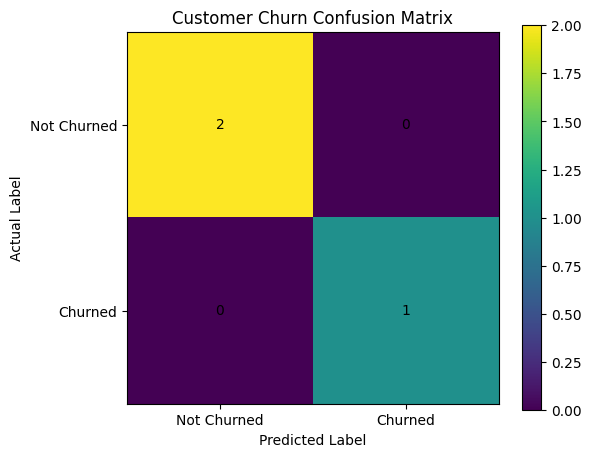

In [ ]:
# ============================================
# CELL 22B - CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print("CONFUSION MATRIX")
print("=" * 50)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Customer Churn Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Add axis labels
plt.xticks(
    [0, 1],
    ["Not Churned", "Churned"]
)

plt.yticks(
    [0, 1],
    ["Not Churned", "Churned"]
)

# Add numbers inside the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [ ]:
# ============================================
# CELL 23 - BASELINE VS ML
# ============================================

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Non_ML_Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],

    "Logistic_Regression": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

comparison[
    ["Non_ML_Baseline", "Logistic_Regression"]
] = comparison[
    ["Non_ML_Baseline", "Logistic_Regression"]
].round(4)

display(comparison)

,Metric,Non_ML_Baseline,Logistic_Regression
0,Accuracy,0.5833,1.0
1,Precision,0.0000,1.0
2,Recall,0.0000,1.0
3,F1 Score,0.0000,1.0


In [ ]:
# False-Positive and False-Negative Analysis

## False Positive

A false positive occurs when the model predicts that a customer will churn, but the customer actually does not churn.

Potential consequences:

- Unnecessary retention communication
- Unnecessary discounts or incentives
- Additional employee workload
- Possible customer annoyance

## False Negative

A false negative occurs when the model predicts that a customer will not churn, but the customer actually churns.

Potential consequences:

- Missed retention opportunity
- Potential revenue loss
- Loss of customer relationship

## Business Trade-off

False positives and false negatives do not necessarily have the same business cost.

The actual costs should be determined by the organization using real business information.

Therefore, accuracy should not be the only metric used to evaluate the system.

Precision and recall should also be considered.

In [ ]:
# Human Review and Abstention

The churn prediction model should be treated as a decision-support system rather than an automatic decision-maker.

## High-Confidence Cases

High-confidence predictions may be used to prioritize customers for an approved retention workflow.

## Uncertain Cases

If the model is uncertain, it should abstain from making an automated recommendation and send the case for human review.

## Human Reviewer

The reviewer can consider:

- Customer history
- Support tickets
- Recent login activity
- Subscription plan
- Other relevant information available at prediction time

The reviewer should be able to override the model recommendation.

## Important Principle

The model should assist human decision-making rather than automatically making high-impact decisions about customers.

In [ ]:
# Monitoring Plan

The system should be monitored after deployment.

## 1. Data Quality Monitoring

Monitor:

- Missing values
- Invalid values
- Unexpected plan types
- Changes in feature distributions

## 2. Model Monitoring

Monitor:

- Accuracy
- Precision
- Recall
- F1 Score
- False positives
- False negatives

## 3. Data Drift

Monitor whether customer behavior and important feature distributions change substantially compared with the training data.

## 4. Business Monitoring

Monitor:

- Retention response
- Cost of interventions
- Customer complaints
- Customers successfully retained

## 5. Review

The model should be periodically reviewed to determine whether it remains appropriate for its intended use.

## Dataset Limitation

The supplied dataset contains only 12 observations. Therefore, its evaluation metrics are highly unstable and should not be interpreted as reliable estimates of real-world performance.

In [ ]:
# Rollback Conditions

The model should be removed from automated decision support if:

1. Input data becomes unreliable.
2. Required features are missing.
3. Significant data drift is detected.
4. Model performance falls below an agreed minimum threshold.
5. False-negative errors become unacceptable.
6. A serious data leakage problem is discovered.
7. Unexpected harmful recommendations are observed.
8. Human reviewers identify repeated systematic errors.

## Fallback

If the model becomes unavailable or fails validation, the organization should return to the approved non-ML baseline and human review process.

In [ ]:
# Responsible Data Card

## 1. Dataset Name

Customer Churn Training Data

## 2. Dataset Size

The supplied dataset contains 12 observations and 7 columns.

## 3. Purpose

The dataset is used to demonstrate responsible machine-learning problem framing and customer churn prediction.

## 4. Intended Use

The dataset is intended for educational and experimental analysis as part of RabTech Academy Task 02.

## 5. Unit of Observation

One row represents one customer.

## 6. Target Variable

The target variable is:

`churned`

Where:

- `0` = customer did not churn
- `1` = customer churned

## 7. Features

The candidate features are:

- `tenure_months`
- `support_tickets`
- `monthly_spend_inr`
- `last_login_days`
- `plan_type`

## 8. Identifier

`customer_id` is treated as an identifier and is excluded from model training.

## 9. Data Provenance

The customer churn training dataset was supplied through the RabTech Academy task materials.

The original collection process, collection date, original data owner, and preprocessing history should be verified from the official dataset documentation.

## 10. Consent

The consent status and legal basis for the original collection are not assumed merely because the dataset was supplied for this educational task.

The data owner should verify the applicable consent and data-use requirements.

## 11. Sensitive Attributes

No explicit demographic attributes were observed in the supplied columns.

`monthly_spend_inr` may indirectly reflect economic circumstances and should be reviewed before real-world use.

## 12. Missing Data

The notebook calculates missing-value counts and percentages for all columns.

Missing values should be documented and handled using an appropriate preprocessing method.

## 13. Leakage Risk

Information that becomes available only after the prediction point or directly reveals the churn outcome must not be used as an input feature.

The exact availability time of each feature should be verified before production deployment.

## 14. Limitations

The dataset contains only 12 observations.

Therefore:

- Model metrics are highly unstable.
- The dataset may not represent the full customer population.
- Results should not be interpreted as production-level performance.
- More representative data would be required for real-world deployment.

## 15. Misuse Risks

Potential misuse includes:

- Automatically making customer decisions
- Treating predictions as certain facts
- Using the model outside its intended population
- Ignoring false negatives
- Ignoring potential bias
- Using future information
- Using the model without human oversight

## 16. Human Oversight

Uncertain or high-impact cases should be reviewed by an appropriate human decision-maker.

## 17. Monitoring

Monitor:

- Data quality
- Model performance
- False positives
- False negatives
- Data drift
- Business outcomes

## 18. Rollback

If the model becomes unreliable, the system should return to the approved non-ML process and human review.

## 19. Version

RabTech Academy Task 02 - Educational Version

In [ ]:
# ============================================
# CELL 29 - RISK REGISTER
# ============================================

risk_register = pd.DataFrame({
    "Risk": [
        "Data leakage",
        "Very small dataset",
        "Missing values",
        "Class imbalance",
        "Sensitive attribute risk",
        "False positives",
        "False negatives",
        "Data drift",
        "Automation over-reliance"
    ],

    "Potential_Impact": [
        "Artificially high model performance",
        "Unstable evaluation and poor generalization",
        "Unreliable model inputs",
        "Poor detection of the minority class",
        "Potential inappropriate or unfair use",
        "Unnecessary retention actions",
        "Missed churners",
        "Model performance may degrade",
        "Human judgment may be ignored"
    ],

    "Mitigation": [
        "Exclude future or outcome-derived information",
        "Collect and validate more representative data",
        "Document and appropriately handle missing values",
        "Use precision, recall and F1 in addition to accuracy",
        "Review potentially sensitive features before use",
        "Monitor precision and intervention costs",
        "Monitor recall and missed churn cases",
        "Monitor feature and prediction distributions",
        "Require human review for uncertain cases"
    ],

    "Owner": [
        "ML Engineer",
        "Project Owner",
        "Data Engineer",
        "ML Engineer",
        "Data/Privacy Reviewer",
        "Business Team",
        "Business + ML Team",
        "ML Engineer",
        "Business Team"
    ]
})

display(risk_register)

,Risk,Potential_Impact,Mitigation,Owner
0,Data leakage,Artificially high model performance,Exclude future or outcome-derived information,ML Engineer
1,Very small dataset,Unstable evaluation and poor generalization,Collect and validate more representative data,Project Owner
2,Missing values,Unreliable model inputs,Document and appropriately handle missing values,Data Engineer
3,Class imbalance,Poor detection of the minority class,"Use precision, recall and F1 in addition to ac...",ML Engineer
4,Sensitive attribute risk,Potential inappropriate or unfair use,Review potentially sensitive features before use,Data/Privacy Reviewer
5,False positives,Unnecessary retention actions,Monitor precision and intervention costs,Business Team
6,False negatives,Missed churners,Monitor recall and missed churn cases,Business + ML Team
7,Data drift,Model performance may degrade,Monitor feature and prediction distributions,ML Engineer
8,Automation over-reliance,Human judgment may be ignored,Require human review for uncertain cases,Business Team


In [ ]:
# ============================================
# CELL 30 - SAVE RISK REGISTER & EVIDENCE FILES
# ============================================

# Make sure pandas is available
import pandas as pd

# --------------------------------------------
# 1. SAVE RISK REGISTER
# --------------------------------------------

risk_register.to_csv(
    "RabTech_Task_02_Risk_Register.csv",
    index=False
)

# --------------------------------------------
# 2. CREATE AND SAVE DATA QUALITY REPORT
# --------------------------------------------

missing_report = pd.DataFrame({
    "Column": df.columns,
    "Missing_Values": df.isnull().sum().values,
    "Data_Type": df.dtypes.astype(str).values
})

missing_report.to_csv(
    "RabTech_Task_02_Data_Quality_Report.csv",
    index=False
)

# --------------------------------------------
# 3. SAVE MODEL COMPARISON
# --------------------------------------------

comparison.to_csv(
    "RabTech_Task_02_Model_Comparison.csv",
    index=False
)

# --------------------------------------------
# 4. CONFIRM FILES
# --------------------------------------------

print("All evidence files created successfully!")
print("\nFiles created:")
print("1. RabTech_Task_02_Risk_Register.csv")
print("2. RabTech_Task_02_Data_Quality_Report.csv")
print("3. RabTech_Task_02_Model_Comparison.csv")

All evidence files created successfully!

Files created:
1. RabTech_Task_02_Risk_Register.csv
2. RabTech_Task_02_Data_Quality_Report.csv
3. RabTech_Task_02_Model_Comparison.csv


In [ ]:
# Final Conclusion

The customer churn problem was framed as a supervised binary classification problem.

The target variable is `churned`, where:

- `0` represents a customer who did not churn.
- `1` represents a customer who churned.

The dataset was examined for:

- Missing values
- Duplicate records
- Data types
- Target distribution
- Sensitive attribute considerations
- Data leakage risks

A majority-class non-ML baseline was established before training a Logistic Regression baseline.

The ML model was evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

False-positive and false-negative consequences were documented.

A responsible deployment approach was also defined, including:

- Human review
- Abstention for uncertain cases
- Monitoring
- Data-drift monitoring
- Rollback conditions
- Fallback to the non-ML process

Because the supplied dataset contains only 12 observations, the model results are intended only as an educational demonstration and should not be considered evidence of production performance.

The responsible data card and risk register document the dataset's intended use, limitations, risks, mitigation strategies, and human-oversight requirements.

In [ ]:
# ============================================
# CELL 32 - DOWNLOAD EVIDENCE
# ============================================

from google.colab import files

print("Evidence files ready:")
print("1. RabTech_Task_02_Risk_Register.csv")
print("2. RabTech_Task_02_Data_Quality_Report.csv")
print("3. RabTech_Task_02_Model_Comparison.csv")

Evidence files ready:
1. RabTech_Task_02_Risk_Register.csv
2. RabTech_Task_02_Data_Quality_Report.csv
3. RabTech_Task_02_Model_Comparison.csv


In [ ]:
files.download(
    "RabTech_Task_02_Risk_Register.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(
    "RabTech_Task_02_Model_Comparison.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>